The "clustering.csv" consists of marks of 1000 students on 10 courses. We will see whether clustering can help identify students with different patterns of achievement across these courses.

**K-Means Clustering**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
# 1. Read CSV file 
df = pd.read_csv("clustering.csv")

In [3]:
# Preview data: First 5 rows of the dataset 
print(df.head())

# Summary statistics
print(df.describe())


   M1Q1  M1Q2  M1Q3  M1Q4  M1Q5  M2Q1  M2Q2  M2Q3  M2Q4   M2Q5
0  70.1  77.6  75.5  67.0  71.4  81.1  82.9  90.3  73.5   73.4
1  77.6  78.9  70.8  70.0  71.3  63.4  69.8  72.6  69.6   74.9
2  67.6  63.4  68.6  71.1  56.3  68.2  67.6  35.9  65.2   50.5
3  72.4  73.7  69.6  76.7  72.6  67.1  74.4  72.3  74.8   73.4
4  85.2  71.4  75.4  78.9  70.5  85.3  73.7  60.6  67.4  100.0
              M1Q1        M1Q2         M1Q3         M1Q4         M1Q5  \
count  1000.000000  1000.00000  1000.000000  1000.000000  1000.000000   
mean     73.896600    73.17000    74.527600    71.157000    68.609500   
std       7.217133     6.56655     7.913472    11.202951    12.906182   
min      45.700000    48.80000    45.700000    33.800000    20.600000   
25%      69.100000    69.10000    69.400000    64.400000    61.375000   
50%      74.000000    73.50000    75.000000    71.300000    70.550000   
75%      78.225000    77.50000    79.600000    78.900000    77.200000   
max      94.300000    95.60000   100.0

In [4]:
# Use all columns for clustering
X = df.values  

# Standardise data (Optional)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

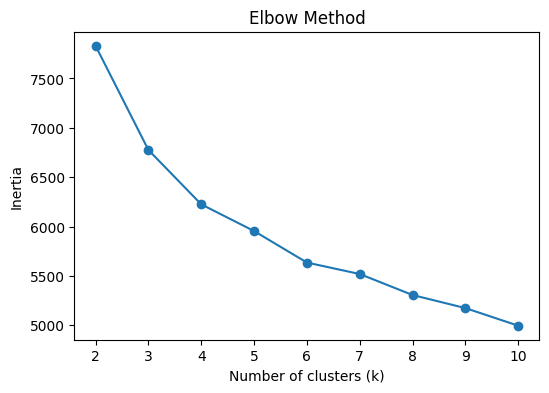

In [5]:
# 2. Determine appropriate number of clusters
# ---- Elbow Method ----
inertia = []
K_range = range(2, 11)  # Try cluster counts from 2 to 10
for k in K_range:
    km = KMeans(n_clusters=k, random_state=1)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()

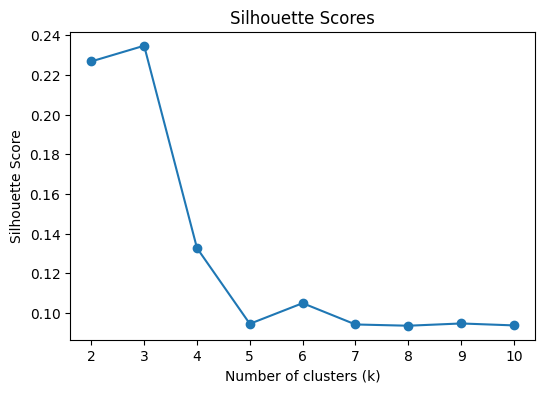

In [6]:
# ---- Silhouette Score ----
silhouette_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=1)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(K_range, silhouette_scores, marker="o")
plt.title("Silhouette Scores")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

In [7]:
# Determine the `best` k (from the elbow method and silhouette method, together with domain knowledge)
k = 3

In [8]:
# 3. Apply K-Means clustering
kmeans = KMeans(n_clusters=k, random_state=1)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster counts:")
print(df["Cluster"].value_counts())


Cluster counts:
Cluster
2    580
1    265
0    155
Name: count, dtype: int64


In [9]:
# 4. Calculate and visualise centroids
centroids = kmeans.cluster_centers_
centroids_unscaled = scaler.inverse_transform(centroids)
centroid_df = pd.DataFrame(centroids_unscaled, columns=df.columns[:-1])  # exclude "Cluster"
print("\nCluster centroids (original scale):")
print(centroid_df)


Cluster centroids (original scale):
        M1Q1       M1Q2       M1Q3       M1Q4       M1Q5       M2Q1  \
0  79.613548  75.640645  79.794194  76.670323  71.818065  74.348387   
1  67.880377  66.875472  66.331321  60.083019  55.775849  72.013962   
2  75.117586  75.385690  76.865000  74.743276  73.615690  76.007069   

        M2Q2       M2Q3       M2Q4       M2Q5  
0  62.458065  49.623226  52.025161  43.147742  
1  69.351321  63.228679  66.311321  60.954340  
2  75.566207  75.142241  75.787241  74.977931  


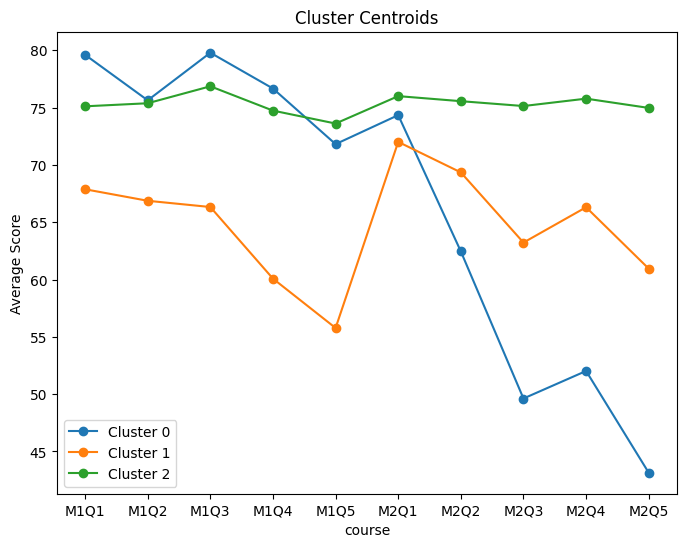

In [10]:
# Plot centroids as line plots (one per cluster)
plt.figure(figsize=(8,6))
for i, row in centroid_df.iterrows():
    plt.plot(df.columns[:-1], row, marker="o", label=f"Cluster {i}")

plt.title("Cluster Centroids")
plt.xlabel("course")
plt.ylabel("Average Score")
plt.legend()
plt.show()